In [7]:
import pandas as pd
df = pd.read_excel('C:\\Users\\SERVER\\Downloads\\customer_reviews_dataset.xlsx')

In [12]:
df.head()

,customer_id,age,income,years_experience,city,device,product_category,rating,purchased
0,1,23,25000,1,Nairobi,Mobile,Electronics,4,Yes
1,2,45,120000,20,Mombasa,Laptop,Home,5,Yes
2,3,34,54000,8,Kisumu,Tablet,Electronics,3,No
3,4,29,48000,5,Nairobi,Mobile,Fashion,4,Yes
4,5,52,220000,25,Nakuru,Laptop,Home,5,Yes


In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
df['device']

0     Mobile
1     Laptop
2     Tablet
3     Mobile
4     Laptop
5     Mobile
6     Tablet
7     Mobile
8     Laptop
9     Mobile
10    Tablet
11    Laptop
12    Mobile
13    Mobile
14    Tablet
15    Laptop
16    Mobile
17    Tablet
18    Laptop
19    Mobile
Name: device, dtype: str

In [15]:
device = ['Mobile', 'Laptop', 'Tablet']
le = LabelEncoder()
encode_devices = le.fit_transform(device)
print(encode_devices)

[1 0 2]


In [17]:
df['city']

0     Nairobi
1     Mombasa
2      Kisumu
3     Nairobi
4      Nakuru
5     Eldoret
6     Nairobi
7     Mombasa
8      Kisumu
9      Nakuru
10    Eldoret
11    Nairobi
12    Mombasa
13     Kisumu
14     Nakuru
15    Eldoret
16    Nairobi
17    Mombasa
18     Kisumu
19     Nakuru
Name: city, dtype: str

In [18]:
city = ['Nairobi', 'Kisumu', 'Eldoret', 'Mombasa']

In [50]:
encoded_city = le.fit_transform(city)

ValueError: Length of values (4) does not match length of index (20)

In [24]:
from sklearn.preprocessing import KBinsDiscretizer
import numpy as np

# Reshape your column to 2D array
X = df['age'].values.reshape(-1, 1)

# Create binner
binner = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')

# Fit and transform
age_binned = binner.fit_transform(X)
df['age_binned'] = age_binned.astype(int)

In [29]:
y = df['income'].values.reshape(-1, 1)

In [31]:
income_binned = binner.fit_transform(y)
df['income_binned'] = income_binned.astype(int)

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
columns = ['age', 'income', 'years_experience']
df[columns] = scaler.fit_transform(df[columns])

In [42]:
df[columns]

,age,income,years_experience
0,0.029412,0.014337,0.000000
1,0.676471,0.354839,0.655172
2,0.352941,0.118280,0.241379
3,0.205882,0.096774,0.137931
4,0.882353,0.713262,0.827586
5,0.558824,0.164875,0.379310
6,0.441176,0.182796,0.310345
7,0.117647,0.035842,0.068966
8,0.764706,0.275986,0.724138
9,0.264706,0.086022,0.172414


TO PREVENT DATA LEAKAGE

In [52]:
from sklearn.model_selection import train_test_split
x = df.drop('purchased', axis=1, )
y = df['purchased']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [60]:
num_cols = ['age', 'income', 'years_experience']
cat_cols = ['city', 'device', 'product_category']
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(), cat_cols)
    ]
)

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression())
])

In [62]:
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [64]:
predictions = pipeline.predict(x_test)

In [65]:
print(predictions)

['No' 'No' 'Yes' 'Yes']


In [66]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, predictions)

0.75

In [5]:
df.head()

NameError: name 'df' is not defined

POLYNOMIAL REGRESSION

Text(0, 0.5, 'age')

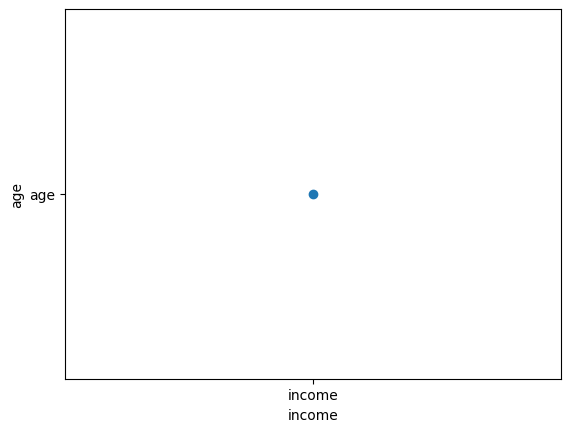

In [4]:
import matplotlib.pyplot as plt
plt.scatter('income', 'age')
plt.xlabel('income')
plt.ylabel('age')